In [1]:
from sklearn.metrics import mutual_info_score
from os import listdir
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
#from dit import Distribution
#from dit.multivariate import coinformation
import seaborn as sns
from collections import Counter

new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
plt.rcParams.update(new_rc_params)

In [11]:
def load_data(directory, population, var_of_interest, inhib=True):
    neural_act = []
    stim_id = []
    if inhib:
        inhib_folder = 'Scale1_inhib/'
    else:
        inhib_folder = 'Scale1_no_inhib/'
    for f in listdir('./neural_activity/' + inhib_folder + directory + population + var_of_interest):
        neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
        stim_id.append(Path(f).stem)
    neural_act = np.asarray(neural_act, dtype='object')
    return neural_act, np.asarray(stim_id, dtype=int)

In [2]:
def load_spiketimes(directory, population, rank, inhib=True):
    neural_act = []
    stim_id = []
    if inhib:
        inhib_folder = 'Scale1_inhib/'
    else:
        inhib_folder = 'Scale1_no_inhib/'
    for f in listdir('./neural_activity/' + inhib_folder + directory + population + '/spike_time'):
        sp_time = np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + '/spike_time' + '/' + f, delimiter=',')
        if np.unique(sp_time).size==0:
            sp_time = 0
        else:
            sp_time = np.unique(sp_time)[rank]
        neural_act.append(sp_time)
        stim_id.append(Path(f).stem)
    neural_act = np.asarray(neural_act)
    return neural_act, np.asarray(stim_id, dtype=int)


In [3]:
def load_spiketime_per_neuron(directory, population, populationsize, rank):
    neuron_ids, stim_id = load_data(directory, population, '/spike_id')
    neuron_sptime, _ = load_data(directory, population, '/spike_time')
    sp_time_per_neuron = np.zeros((len(stim_id), populationsize))
    for j in range(len(stim_id)):
        #sp_time_per_neuron_per_stim = []
        for i in range(populationsize):
            #sp_time_per_neuron_per_stim.append(neuron_sptime[j][np.where(neuron_ids[j] == i)])
            try:
                sp_time_per_neuron[j, i] = neuron_sptime[j][np.where(neuron_ids[j] == i)][rank]
            except:
                pass
        #sp_time_per_neuron.append(sp_time_per_neuron_per_stim)
    return sp_time_per_neuron, stim_id

In [4]:
def compute_nb_spike_per_neuron(data, popsize):
    data = np.asarray(data, dtype=int)
    spike_per_neuron = np.zeros(popsize)
    for i in np.unique(data):
        spike_per_neuron[i] = np.sum(np.where(data == i, 1, 0))

    return spike_per_neuron

In [5]:
def make_dist(data):
    data = np.asarray(data)
    uniqueness = np.unique(data)
    prob = np.zeros(len(uniqueness))
    for idx, i in enumerate(uniqueness):
        prob[idx] = sum(data == i)
    return prob/len(uniqueness)

In [6]:
def create_dit_dist(data1, data2, stim_values):
    data = zip(data1, data2, stim_values)

    counts = Counter(data)
    total_count = sum(list(counts.values()))

    outcomes = list(counts.keys())
    probabilities = [count / total_count for count in counts.values()]

    return Distribution(outcomes, probabilities)


In [7]:
import numpy as np
import dit
#from dit import distributions
# Example distribution for testing
close = 0
equal = 0
for i in range(1000):
    X = np.random.randint(0, 3, 100)  # Three possible states (0,1,2)
    Y = np.random.randint(0, 3, 100)
    Z = np.random.randint(0, 3, 100)
    dist = create_dit_dist(X, Y, Z)

    # Using dit's coinformation calculation
    coinf_dit = dit.multivariate.coinformation(dist)

    # Your manual computation (example, make sure you are using the correct formula)
    # This part depends on how you've implemented entropy, joint entropy, etc.
    coinf_manual = co_information(X, Y, Z)

    # Compare results with a tolerance
    close += np.isclose(coinf_dit, coinf_manual, atol=1e-10)
    equal += coinf_dit == coinf_manual # Adjust tolerance as needed
print(close)
print(equal)

AttributeError: `np.alltrue` was removed in the NumPy 2.0 release. Use `np.all` instead.

In [17]:
import numpy as np

def compute_joint_distribution(*variables):
    """ Compute the joint probability distribution of multiple discrete variables. """
    stacked_vars = np.column_stack(variables)  # Stack input variables as columns
    unique_vals = [np.unique(var) for var in variables]  # Unique states per variable
    bins = [len(vals) for vals in unique_vals]  # Number of bins per variable
    
    joint_counts, _ = np.histogramdd(stacked_vars, bins=bins)  # Joint histogram
    joint_prob = joint_counts / joint_counts.sum()  # Normalize to get probabilities
    
    return joint_prob

def sh_entropy(*variables):
    """ Compute entropy given one or more discrete variables. """
    prob_dist = compute_joint_distribution(*variables)
    prob_dist = prob_dist[prob_dist > 0]  # Remove zero probabilities
    return -np.sum(prob_dist * np.log2(prob_dist))

def co_information(X, Y, Z):
    """ Compute coinformation using entropy. """
    H_X = sh_entropy(X)
    H_Y = sh_entropy(Y)
    H_Z = sh_entropy(Z)
    H_XY = sh_entropy(X, Y)
    H_XZ = sh_entropy(X, Z)
    H_YZ = sh_entropy(Y, Z)
    H_XYZ = sh_entropy(X, Y, Z)


    co_inf = H_X + H_Y + H_Z - H_XY - H_XZ - H_YZ + H_XYZ

    if np.isclose(co_inf, 0, atol=1e-15):  # Adjust tolerance if necessary
        co_inf = 0
    return co_inf

# Example usage
X = np.random.randint(0, 3, 100)  # Three possible states (0,1,2)
Y = np.random.randint(0, 3, 100)
Z = np.random.randint(0, 3, 100)

coinf = co_information(X, Y, Z)
print(f"Coinformation: {coinf}")


Coinformation: -0.0731496875710187


# Amplitude

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list

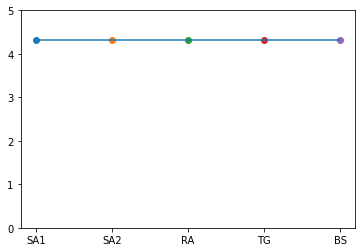

<AxesSubplot:>

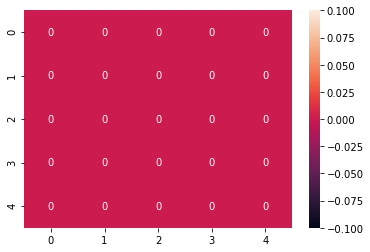

In [37]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

MI_per_pop = []
for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_amplitude', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    MI_per_pop.append(spike_per_neuron_per_stimulus.sum(axis=1))
    plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.hlines(entropy(dist_stim, base=2), 0, 4)
plt.xticks(np.arange(0,5), Populations)
plt.ylim(0, 5)
plt.savefig('./Figures/MI/freq_amp.svg')
plt.show()
coinf = np.zeros((5,5))
for i in range(len(Populations)):
    for j in range(len(Populations)):
        coinf[i, j] = co_information(MI_per_pop[i], MI_per_pop[j], dist_stim)
sns.heatmap(coinf, annot=True)

C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_22992\55212611.py:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_amplitude/SA2/spike_id/1.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_22992\55212611.py:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_direction/SA2/spike_id/0.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_22992\55212611.py:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_direction/SA2/spike_id/10.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
C:\Users\Tansu Celikel\AppData\Local\Te

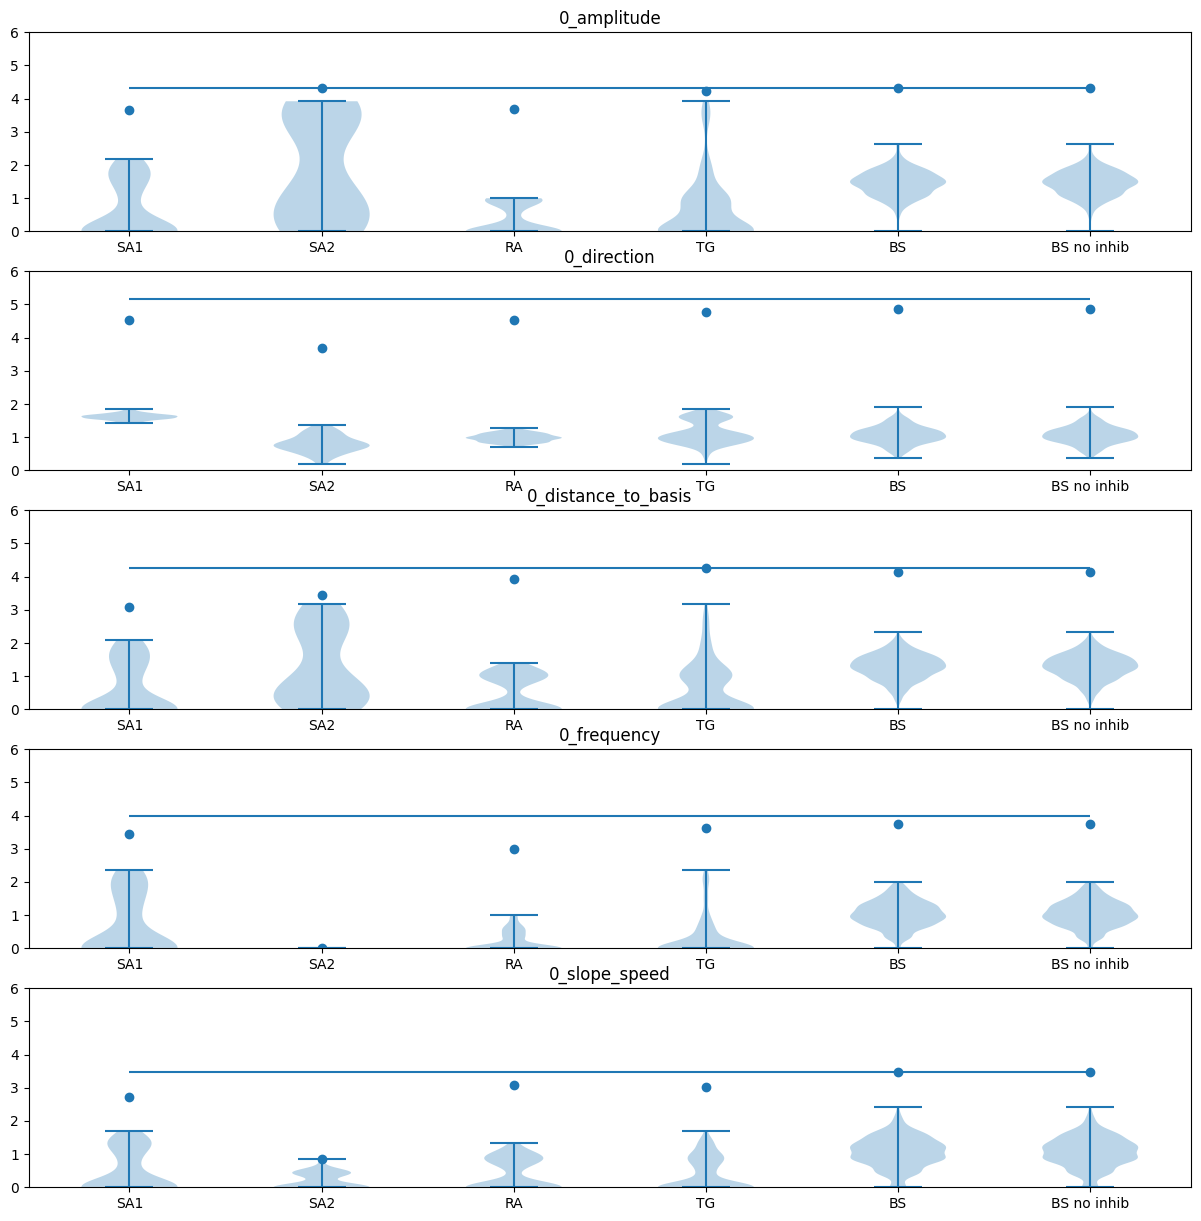

In [16]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS', 'BS']
Populations_label = ['SA1', 'SA2', 'RA', 'TG', 'BS', 'BS no inhib']
inhibition = [True, True, True, True, True, False]
Populations_sizes = [58, 30, 112, 200, 400, 400]
Stimulus = ['0_amplitude', '0_direction', '0_distance_to_basis', '0_frequency', '0_slope_speed']
fig, axs = plt.subplots(5, figsize=(15, 15))
for idx, stim in enumerate(Stimulus):
    best_neurons = []
    mi_per_pop = []
    mi_per_neuron_per_pop = []
    for j in range(len(Populations)):
        mi_per_neuron = []
        popsize = Populations_sizes[j]
        neural_act, stim_id = load_data(stim, '/' + Populations[j], '/spike_id', inhib=inhibition)
        spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
        for i in range(len(spike_per_neuron_per_stimulus)):
            spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
        co_inf = np.zeros((popsize, popsize))
        for i in range(popsize):
            mi_per_neuron.append(mutual_info_score(spike_per_neuron_per_stimulus[:, i], stim_id)/np.log(2))
        full_pop_rate = mutual_info_score(np.sum(spike_per_neuron_per_stimulus, axis=1), stim_id)/np.log(2)
        mi_per_pop.append(full_pop_rate)
        #    for k in range(popsize):
        #        co_inf[i, k] = co_information(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, k], stim_id)
        #sns.heatmap(co_inf)
        #plt.show()
        mi_per_neuron_per_pop.append(mi_per_neuron)#np.asarray(mi_per_neuron)[np.asarray(mi_per_neuron) > 0])
        best_neurons.append(np.asarray(mi_per_neuron).argmax())
        #dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
        dist_stim = make_dist(np.asarray(stim_id, dtype=int))
        
        #plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
    axs[idx].scatter(np.arange(1, 7), mi_per_pop)
    axs[idx].violinplot(mi_per_neuron_per_pop)    
    axs[idx].hlines(entropy(dist_stim, base=2), 1, 6)
    axs[idx].set_ylim(0, 6)
    axs[idx].set_title(stim)
    axs[idx].set_xticks(np.arange(1,7), Populations_label)
    plt.savefig('./Figures/MI/MI_rate.svg')
    #plt.show()
    np.savetxt('./MI_best_neuron_per_stim/' + stim + '.csv', best_neurons, delimiter=',')

In [34]:
np.asarray(mi_per_pop).shape

(6,)

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

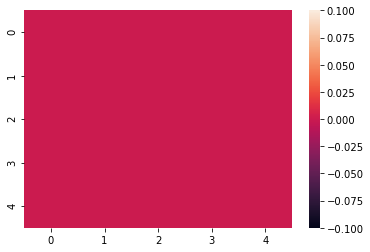

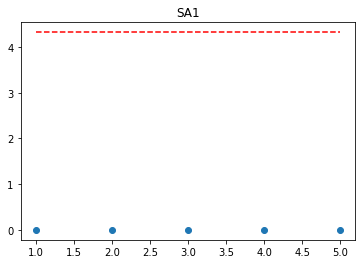

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

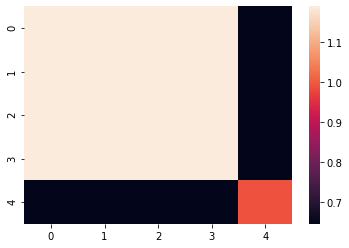

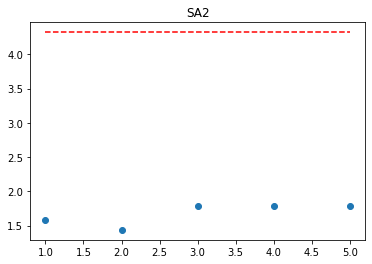

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

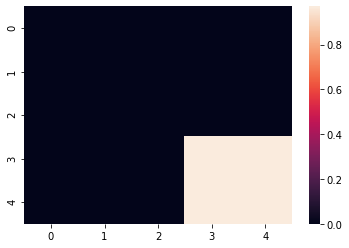

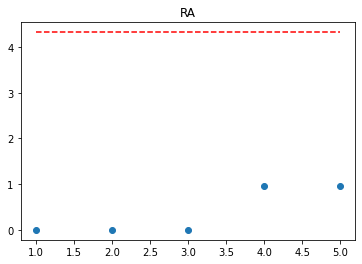

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

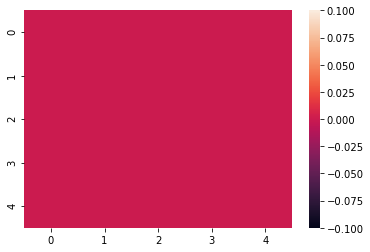

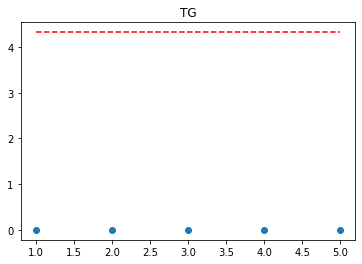

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

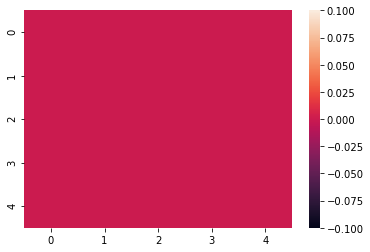

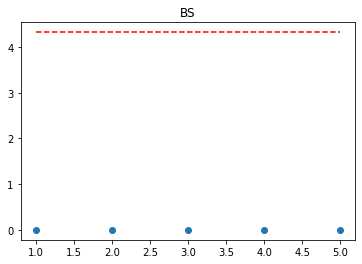

In [39]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
#Within the population
for k in range(len(Populations)):
    mi_per_neuron_per_pop = []
    #Within a rank
    co_inf = np.zeros((ranks, ranks))
    for j in range(ranks):
        sp_time, stim_id = load_spiketimes('0_amplitude', '/' + Populations[k], j)
        #Within a neuron
        #for i in range(Populations_sizes[k]):
        mi_per_neuron_per_pop.append(mutual_info_score(sp_time, stim_id)/np.log(2))
        for i in range(ranks):
            sp_time_2, _ = load_spiketimes('0_amplitude', '/' + Populations[k], i)
            co_inf[j, i] = co_information(sp_time, sp_time_2, stim_id)
    sns.heatmap(co_inf)
    plt.show()
    plt.scatter(np.arange(1, ranks+1), mi_per_neuron_per_pop)
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

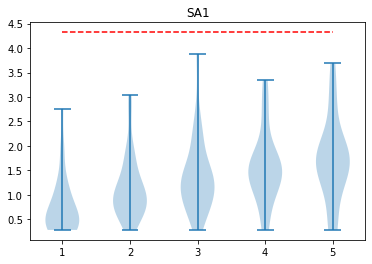

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

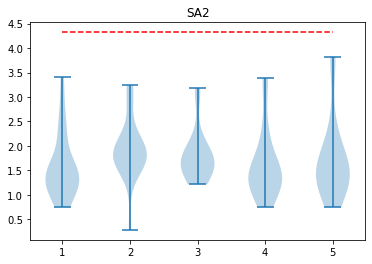

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

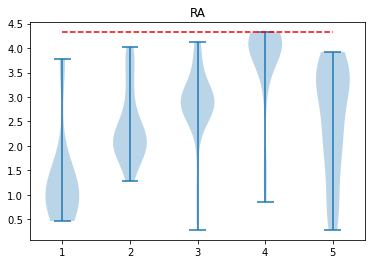

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

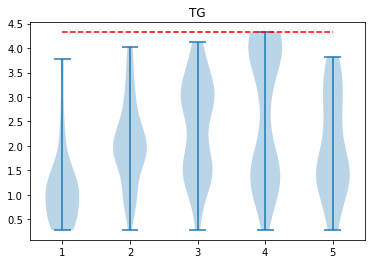

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

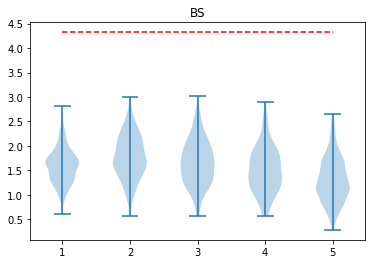

In [40]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
#Within the population
for k in range(len(Populations)):
    mi_per_neuron_per_pop = np.zeros((ranks, Populations_sizes[k]))
    #Within a rank
    for j in range(ranks):
        neural_act, stim_id = load_spiketime_per_neuron('0_amplitude', '/' + Populations[k], Populations_sizes[k], j)
        #Within a neuron
        for i in range(Populations_sizes[k]):
            mi_per_neuron_per_pop[j, i] = mutual_info_score(neural_act[:, i], stim_id)/np.log(2)
    plt.violinplot([mi_per_neuron_per_pop[j, mi_per_neuron_per_pop[j, :] > 0] for j in range(ranks)])
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

# Direction

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list

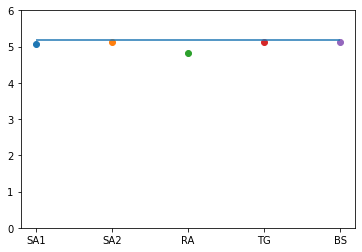

<AxesSubplot:>

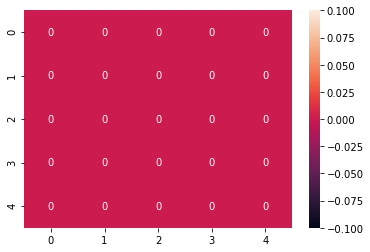

In [41]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

MI_per_pop = []
for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_direction', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    MI_per_pop.append(spike_per_neuron_per_stimulus.sum(axis=1))
    plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.hlines(entropy(dist_stim, base=2), 0, 4)
plt.xticks(np.arange(0,5), Populations)
plt.ylim(0, 6)
plt.savefig('./Figures/MI/freq_dir.svg')
plt.show()
coinf = np.zeros((5,5))
for i in range(len(Populations)):
    for j in range(len(Populations)):
        coinf[i, j] = co_information(MI_per_pop[i], MI_per_pop[j], dist_stim)
sns.heatmap(coinf, annot=True)

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list

[34, 15, 39, 42, 214]


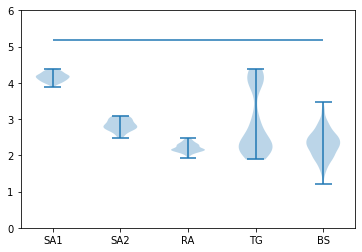

In [42]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
mi_per_neuron_per_pop = []
best_neurons = []
for j in range(len(Populations)):
    mi_per_neuron = []
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_direction', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    co_inf = np.zeros((popsize, popsize))
    for i in range(popsize):
        mi_per_neuron.append(mutual_info_score(spike_per_neuron_per_stimulus[:, i], stim_id)/np.log(2))
    #    for k in range(popsize):
    #        co_inf[i, k] = co_information(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, k], stim_id)
    #sns.heatmap(co_inf)
    #plt.show()
    mi_per_neuron_per_pop.append(np.asarray(mi_per_neuron)[np.asarray(mi_per_neuron) > 0])
    best_neurons.append(np.asarray(mi_per_neuron).argmax())
    #dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    
    #plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.violinplot(mi_per_neuron_per_pop)    
plt.hlines(entropy(dist_stim, base=2), 1, 5)
plt.xticks(np.arange(1,6), Populations)
plt.ylim(0, 6)
print(best_neurons)
plt.savefig('./Figures/MI/single_neuron_dir.svg')

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

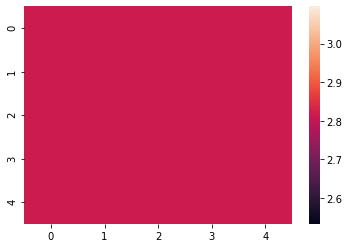

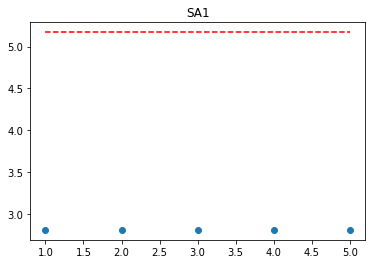

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

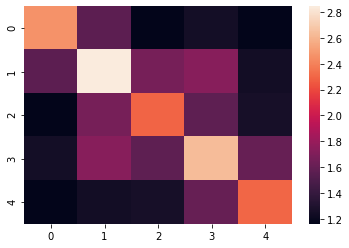

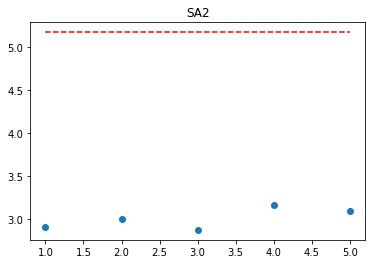

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

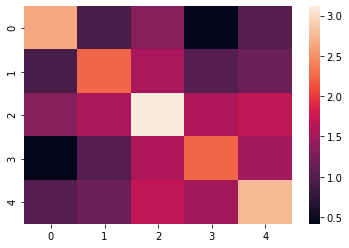

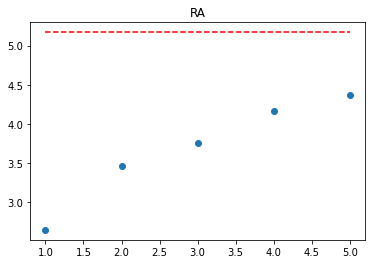

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

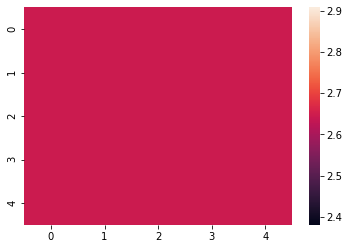

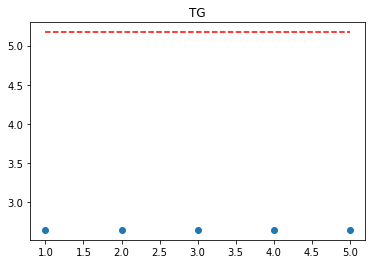

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

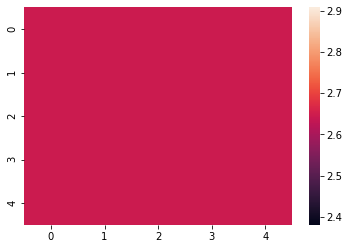

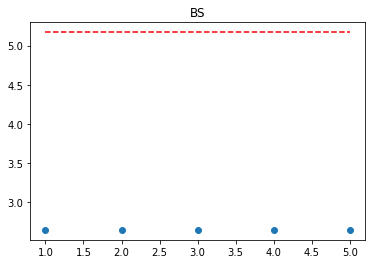

In [43]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
#Within the population
for k in range(len(Populations)):
    mi_per_neuron_per_pop = []
    #Within a rank
    co_inf = np.zeros((ranks, ranks))
    for j in range(ranks):
        sp_time, stim_id = load_spiketimes('0_direction', '/' + Populations[k], j)
        #Within a neuron
        #for i in range(Populations_sizes[k]):
        mi_per_neuron_per_pop.append(mutual_info_score(sp_time, stim_id)/np.log(2))
        for i in range(ranks):
            sp_time_2, _ = load_spiketimes('0_direction', '/' + Populations[k], i)
            co_inf[j, i] = co_information(sp_time, sp_time_2, stim_id)
    sns.heatmap(co_inf)
    plt.show()
    plt.scatter(np.arange(1, ranks+1), mi_per_neuron_per_pop)
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

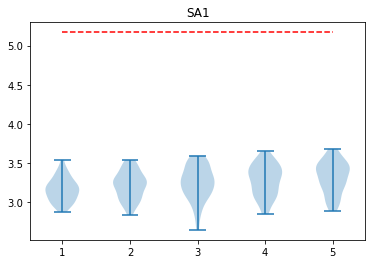

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

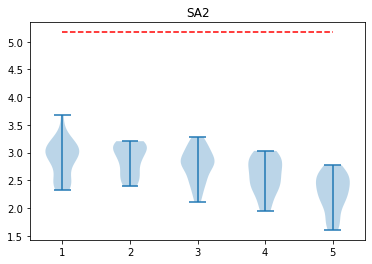

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

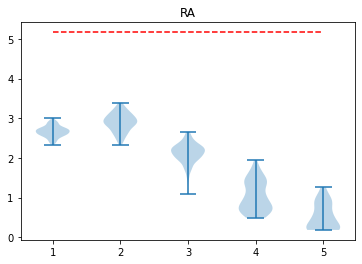

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

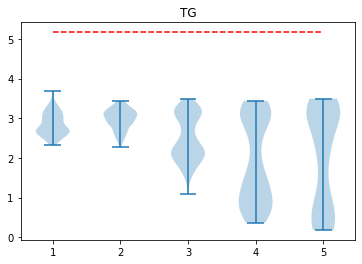

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

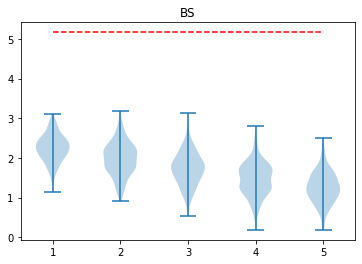

In [44]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
for k in range(len(Populations)):
    mi_per_neuron_per_pop = np.zeros((ranks, Populations_sizes[k]))
    for j in range(ranks):
        neural_act, stim_id = load_spiketime_per_neuron('0_direction', '/' + Populations[k], Populations_sizes[k], j)
        for i in range(Populations_sizes[k]):
            mi_per_neuron_per_pop[j, i] = mutual_info_score(neural_act[:, i], stim_id)/np.log(2)
    plt.violinplot([mi_per_neuron_per_pop[j, mi_per_neuron_per_pop[j, :] > 0] for j in range(ranks)])
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

# Distance to basis

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
<ipython-input-12-bb75675578d7>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_distance_to_basis/SA2/spike_id/19.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, yo

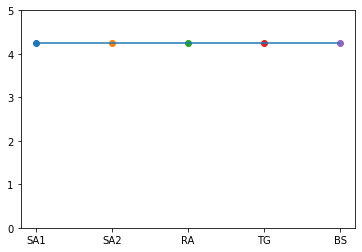

<AxesSubplot:>

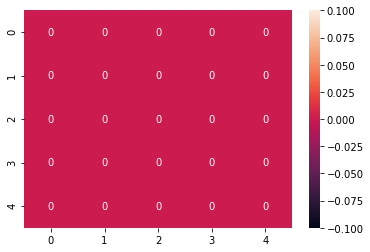

In [45]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

MI_per_pop = []
for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_distance_to_basis', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    MI_per_pop.append(spike_per_neuron_per_stimulus.sum(axis=1))
    plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.hlines(entropy(dist_stim, base=2), 0, 4)
plt.xticks(np.arange(0,5), Populations)
plt.ylim(0, 5)
plt.savefig('./Figures/MI/freq_distance_to_basis.svg')
plt.show()
coinf = np.zeros((5,5))
for i in range(len(Populations)):
    for j in range(len(Populations)):
        coinf[i, j] = co_information(MI_per_pop[i], MI_per_pop[j], dist_stim)
sns.heatmap(coinf, annot=True)

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
<ipython-input-12-bb75675578d7>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_distance_to_basis/SA2/spike_id/19.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, yo

[45, 19, 77, 77, 10]


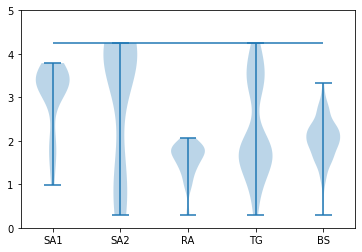

In [46]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
mi_per_neuron_per_pop = []
best_neurons = []
for j in range(len(Populations)):
    mi_per_neuron = []
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_distance_to_basis', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    co_inf = np.zeros((popsize, popsize))
    for i in range(popsize):
        mi_per_neuron.append(mutual_info_score(spike_per_neuron_per_stimulus[:, i], stim_id)/np.log(2))
    #    for k in range(popsize):
    #        co_inf[i, k] = co_information(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, k], stim_id)
    #sns.heatmap(co_inf)
    #plt.show()
    mi_per_neuron_per_pop.append(np.asarray(mi_per_neuron)[np.asarray(mi_per_neuron) > 0])
    best_neurons.append(np.asarray(mi_per_neuron).argmax())
    #dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    
    #plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.violinplot(mi_per_neuron_per_pop)    
plt.hlines(entropy(dist_stim, base=2), 1, 5)
plt.xticks(np.arange(1,6), Populations)
print(best_neurons)
plt.ylim(0,5)
plt.savefig('./Figures/MI/single_neuron_d_to_b.svg')

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

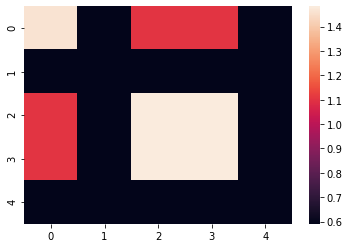

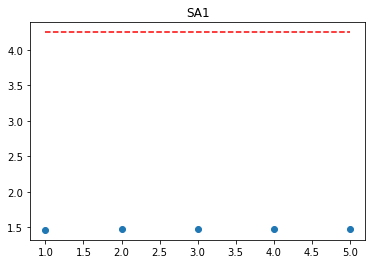

<ipython-input-36-e8827ff9573b>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_distance_to_basis/SA2/spike_time/19.csv"
  sp_time = np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + '/spike_time' + '/' + f, delimiter=',')
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
<ipython-input-36-e8827ff9573b>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_distance_to_basis/SA2/spike_time/19.csv"
  sp_time = np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + '/spike_time' + '/' + f, delimiter=',')
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values b

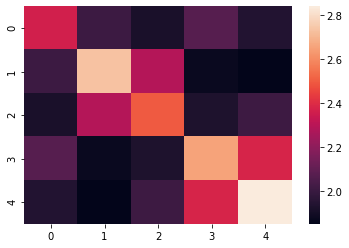

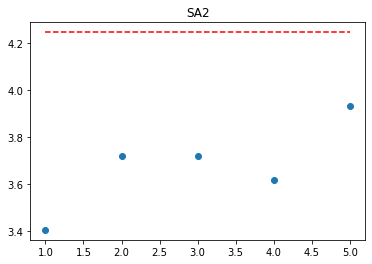

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

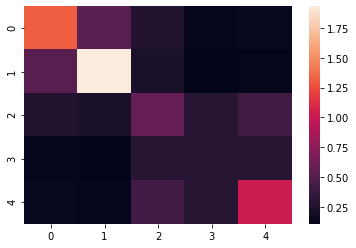

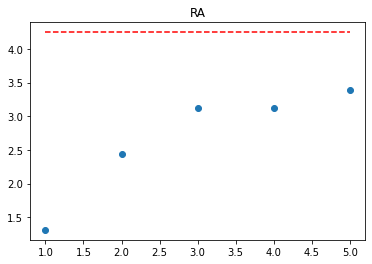

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

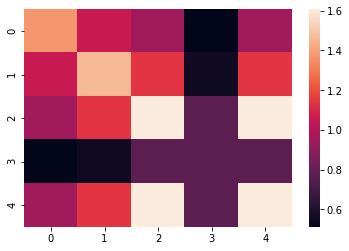

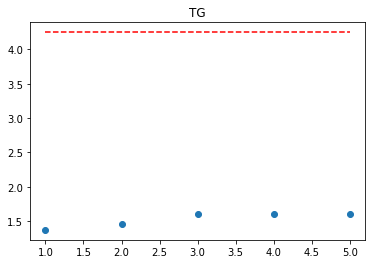

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

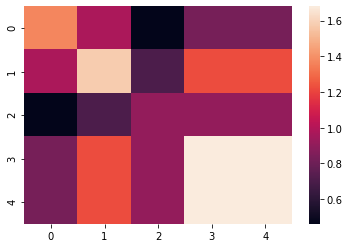

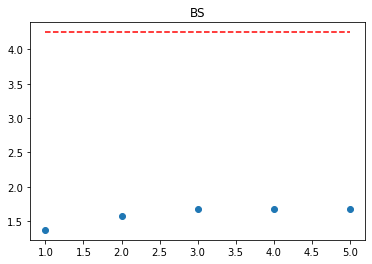

In [47]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
#Within the population
for k in range(len(Populations)):
    mi_per_neuron_per_pop = []
    #Within a rank
    co_inf = np.zeros((ranks, ranks))
    for j in range(ranks):
        sp_time, stim_id = load_spiketimes('0_distance_to_basis', '/' + Populations[k], j)
        #Within a neuron
        #for i in range(Populations_sizes[k]):
        mi_per_neuron_per_pop.append(mutual_info_score(sp_time, stim_id)/np.log(2))
        for i in range(ranks):
            sp_time_2, _ = load_spiketimes('0_distance_to_basis', '/' + Populations[k], i)
            co_inf[j, i] = co_information(sp_time, sp_time_2, stim_id)
    sns.heatmap(co_inf)
    plt.show()
    plt.scatter(np.arange(1, ranks+1), mi_per_neuron_per_pop)
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

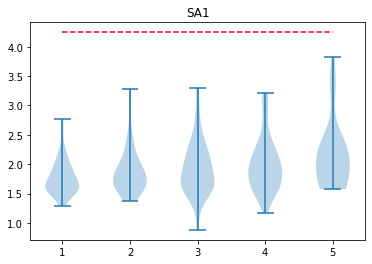

<ipython-input-12-bb75675578d7>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_distance_to_basis/SA2/spike_id/19.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
<ipython-input-12-bb75675578d7>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_distance_to_basis/SA2/spike_time/19.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
c:\Progr

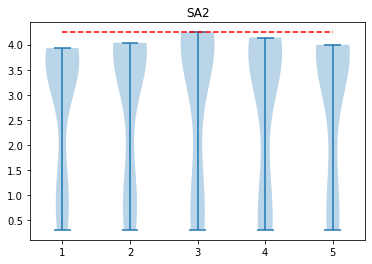

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

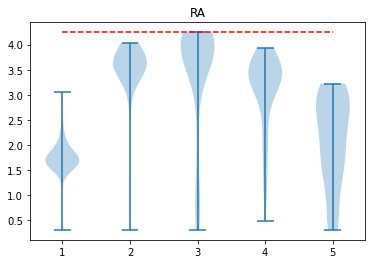

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

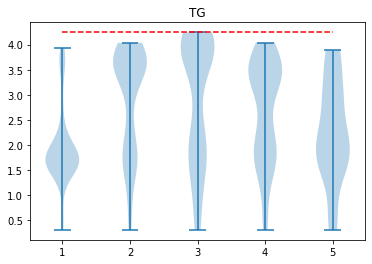

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

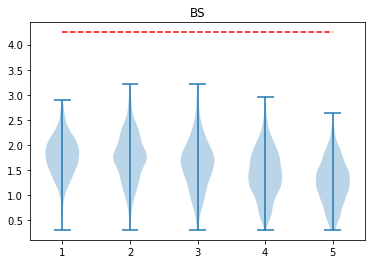

In [48]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
for k in range(len(Populations)):
    mi_per_neuron_per_pop = np.zeros((ranks, Populations_sizes[k]))
    for j in range(ranks):
        neural_act, stim_id = load_spiketime_per_neuron('0_distance_to_basis', '/' + Populations[k], Populations_sizes[k], j)
        for i in range(Populations_sizes[k]):
            mi_per_neuron_per_pop[j, i] = mutual_info_score(neural_act[:, i], stim_id)/np.log(2)
    plt.violinplot([mi_per_neuron_per_pop[j, mi_per_neuron_per_pop[j, :] > 0] for j in range(ranks)])
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

# Frequency

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
<ipython-input-12-bb75675578d7>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_frequency/SA2/spike_id/10.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
<ipython-input-12-bb75675578d7>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_frequency/SA2/spike_id/12.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
<ipython-input-12-bb756755

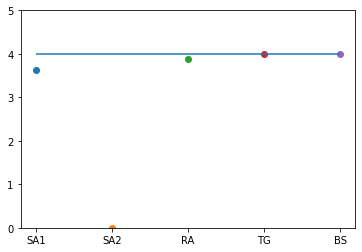

<AxesSubplot:>

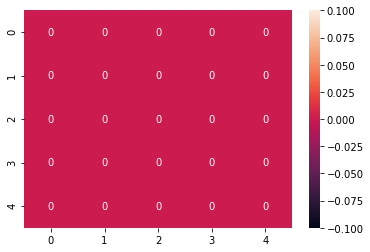

In [49]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

MI_per_pop = []
for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_frequency', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    MI_per_pop.append(spike_per_neuron_per_stimulus.sum(axis=1))
    plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.hlines(entropy(dist_stim, base=2), 0, 4)
plt.xticks(np.arange(0,5), Populations)
plt.ylim(0, 5)
plt.savefig('./Figures/MI/freq_frequency.svg')
plt.show()
coinf = np.zeros((5,5))
for i in range(len(Populations)):
    for j in range(len(Populations)):
        coinf[i, j] = co_information(MI_per_pop[i], MI_per_pop[j], dist_stim)
sns.heatmap(coinf, annot=True)

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
<ipython-input-12-bb75675578d7>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_frequency/SA2/spike_id/10.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
<ipython-input-12-bb75675578d7>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_frequency/SA2/spike_id/12.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
<ipython-input-12-bb756755

[2, 0, 70, 2, 349]


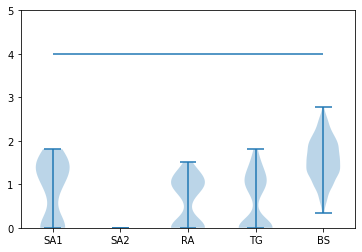

In [51]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
mi_per_neuron_per_pop = []
best_neurons = []
for j in range(len(Populations)):
    mi_per_neuron = []
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_frequency', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    co_inf = np.zeros((popsize, popsize))
    for i in range(popsize):
        mi_per_neuron.append(mutual_info_score(spike_per_neuron_per_stimulus[:, i], stim_id)/np.log(2))
    #    for k in range(popsize):
    #        co_inf[i, k] = co_information(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, k], stim_id)
    #sns.heatmap(co_inf)
    #plt.show()
    mi_per_neuron_per_pop.append(np.asarray(mi_per_neuron))#[np.asarray(mi_per_neuron) > 0])
    best_neurons.append(np.asarray(mi_per_neuron).argmax())
    #dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    
    #plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.violinplot(mi_per_neuron_per_pop)    
plt.hlines(entropy(dist_stim, base=2), 1, 5)
plt.xticks(np.arange(1,6), Populations)
print(best_neurons)
plt.ylim(0, 5)
plt.savefig('./Figures/MI/single_neuron_freq.svg')

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

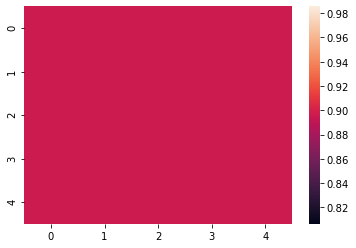

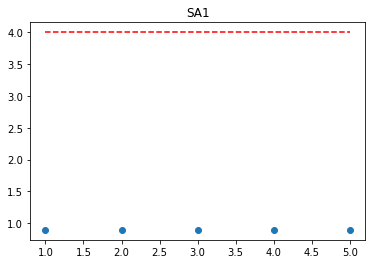

<ipython-input-36-e8827ff9573b>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_frequency/SA2/spike_time/10.csv"
  sp_time = np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + '/spike_time' + '/' + f, delimiter=',')
<ipython-input-36-e8827ff9573b>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_frequency/SA2/spike_time/12.csv"
  sp_time = np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + '/spike_time' + '/' + f, delimiter=',')
<ipython-input-36-e8827ff9573b>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_frequency/SA2/spike_time/14.csv"
  sp_time = np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + '/spike_time' + '/' + f, delimiter=',')
<ipython-input-36-e8827ff9573b>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_frequency/SA2/spike_time/16.csv"
  sp_time = np.genfromtxt('./neur

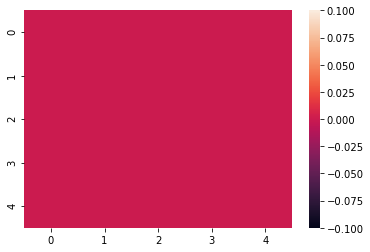

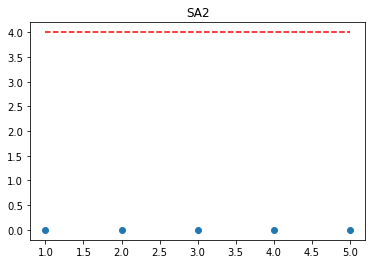

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

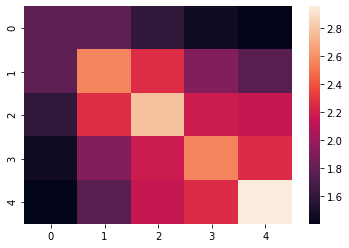

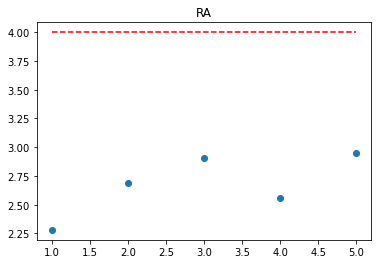

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

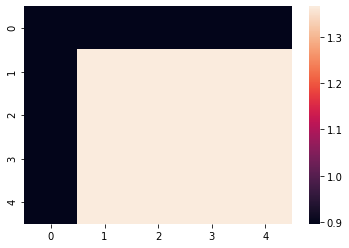

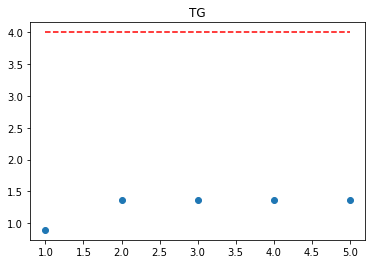

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

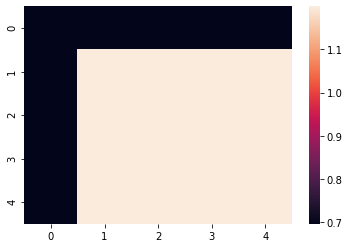

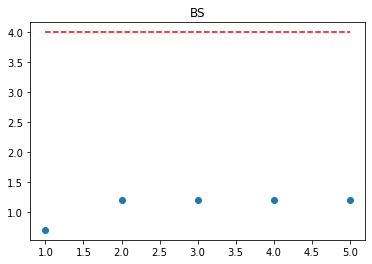

In [52]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
#Within the population
for k in range(len(Populations)):
    mi_per_neuron_per_pop = []
    #Within a rank
    co_inf = np.zeros((ranks, ranks))
    for j in range(ranks):
        sp_time, stim_id = load_spiketimes('0_frequency', '/' + Populations[k], j)
        #Within a neuron
        #for i in range(Populations_sizes[k]):
        mi_per_neuron_per_pop.append(mutual_info_score(sp_time, stim_id)/np.log(2))
        for i in range(ranks):
            sp_time_2, _ = load_spiketimes('0_frequency', '/' + Populations[k], i)
            co_inf[j, i] = co_information(sp_time, sp_time_2, stim_id)
    sns.heatmap(co_inf)
    plt.show()
    plt.scatter(np.arange(1, ranks+1), mi_per_neuron_per_pop)
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

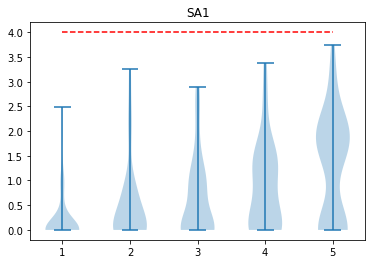

<ipython-input-12-bb75675578d7>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_frequency/SA2/spike_id/10.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
<ipython-input-12-bb75675578d7>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_frequency/SA2/spike_id/12.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
<ipython-input-12-bb75675578d7>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_frequency/SA2/spike_id/14.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
<ipython-input-12-bb75675578d7>:9: UserWarning: genfromtxt: Empty input file: "./neural_activity/Scale1_inhib/0_frequency/SA2/spike_id/16.csv"
  neural

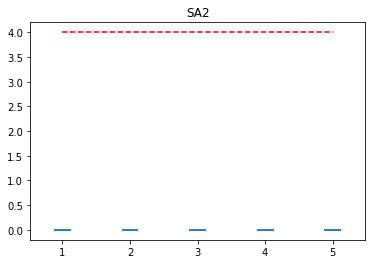

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

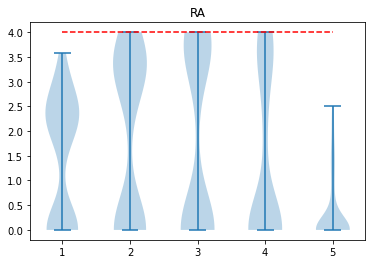

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

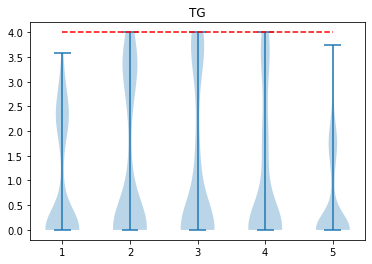

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

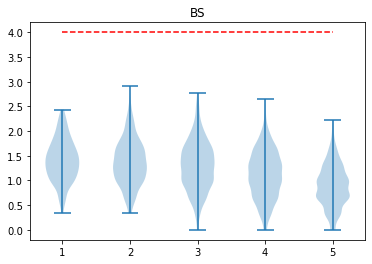

In [61]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
for k in range(len(Populations)):
    mi_per_neuron_per_pop = np.zeros((ranks, Populations_sizes[k]))
    for j in range(ranks):
        neural_act, stim_id = load_spiketime_per_neuron('0_frequency', '/' + Populations[k], Populations_sizes[k], j)
        for i in range(Populations_sizes[k]):
            mi_per_neuron_per_pop[j, i] = mutual_info_score(neural_act[:, i], stim_id)/np.log(2)
    plt.violinplot([mi_per_neuron_per_pop[j, :] for j in range(ranks)])
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

# Slope speed

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list

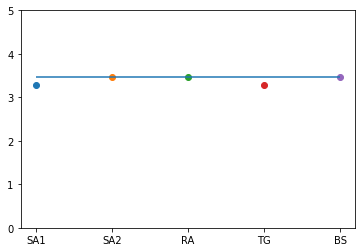

<AxesSubplot:>

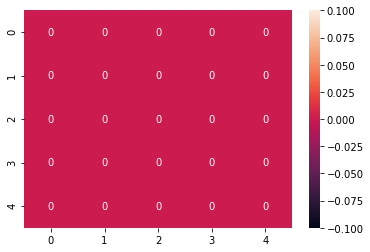

In [62]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

MI_per_pop = []
MI_pop = []
for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_slope_speed', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    MI_per_pop.append(spike_per_neuron_per_stimulus.sum(axis=1))
    plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.hlines(entropy(dist_stim, base=2), 0, 4)
plt.xticks(np.arange(0,5), Populations)
plt.ylim(0, 5)
plt.savefig('./Figures/MI/freq_slope.svg')
plt.show()
coinf = np.zeros((5,5))
for i in range(len(Populations)):
    for j in range(len(Populations)):
        coinf[i, j] = co_information(MI_per_pop[i], MI_per_pop[j], dist_stim)
sns.heatmap(coinf, annot=True)

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list

[41, 20, 82, 45, 64]


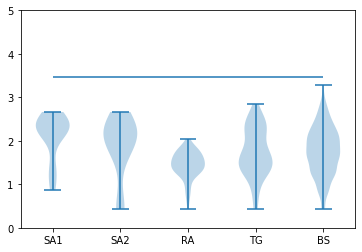

In [63]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
mi_per_neuron_per_pop = []
best_neurons = []
for j in range(len(Populations)):
    mi_per_neuron = []
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_slope_speed', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    co_inf = np.zeros((popsize, popsize))
    for i in range(popsize):
        mi_per_neuron.append(mutual_info_score(spike_per_neuron_per_stimulus[:, i], stim_id)/np.log(2))
    #    for k in range(popsize):
    #        co_inf[i, k] = co_information(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, k], stim_id)
    #sns.heatmap(co_inf)
    #plt.show()
    mi_per_neuron_per_pop.append(np.asarray(mi_per_neuron)[np.asarray(mi_per_neuron) > 0])
    best_neurons.append(np.asarray(mi_per_neuron).argmax())
    #dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    
    #plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.violinplot(mi_per_neuron_per_pop)    
plt.hlines(entropy(dist_stim, base=2), 1, 5)
plt.xticks(np.arange(1,6), Populations)
print(best_neurons)
plt.ylim(0, 5)
plt.savefig('./Figures/MI/single_neuron_slope.svg')

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

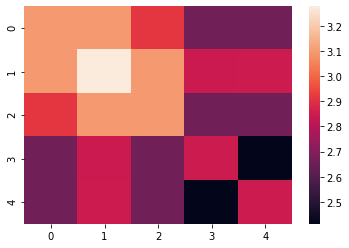

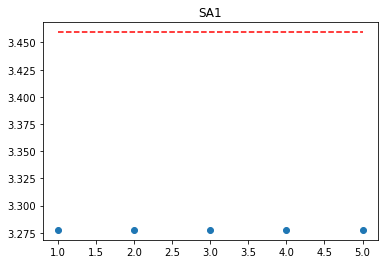

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

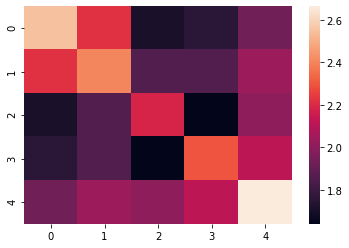

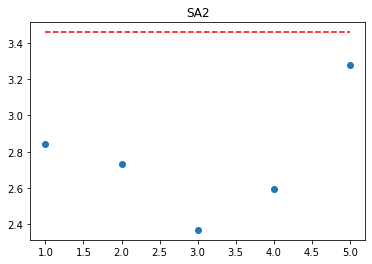

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

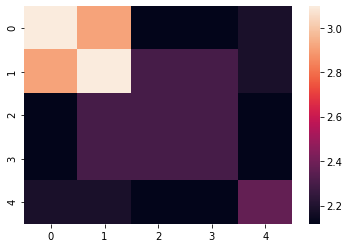

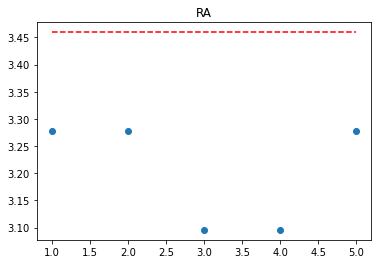

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

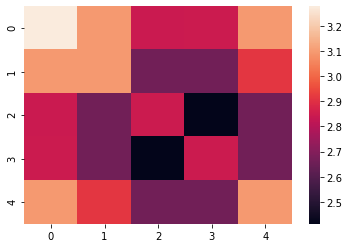

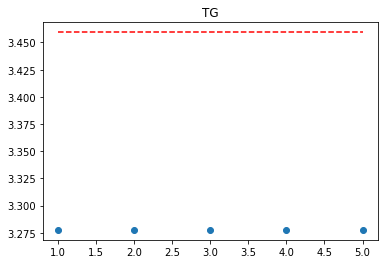

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

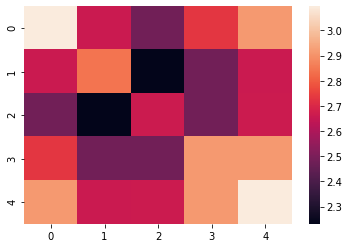

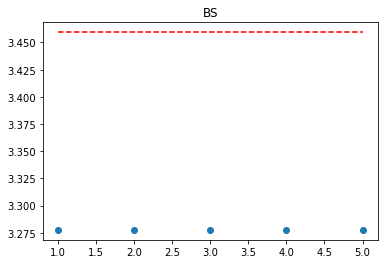

In [64]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
#Within the population
for k in range(len(Populations)):
    mi_per_neuron_per_pop = []
    #Within a rank
    co_inf = np.zeros((ranks, ranks))
    for j in range(ranks):
        sp_time, stim_id = load_spiketimes('0_slope_speed', '/' + Populations[k], j)
        #Within a neuron
        #for i in range(Populations_sizes[k]):
        mi_per_neuron_per_pop.append(mutual_info_score(sp_time, stim_id)/np.log(2))
        for i in range(ranks):
            sp_time_2, _ = load_spiketimes('0_slope_speed', '/' + Populations[k], i)
            co_inf[j, i] = co_information(sp_time, sp_time_2, stim_id)
    sns.heatmap(co_inf)
    plt.show()
    plt.scatter(np.arange(1, ranks+1), mi_per_neuron_per_pop)
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

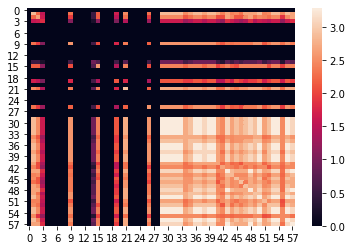

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

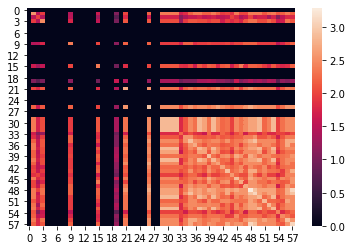

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

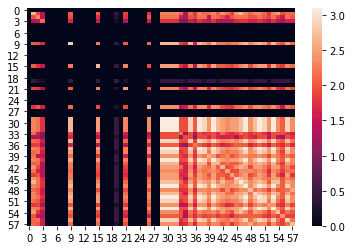

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

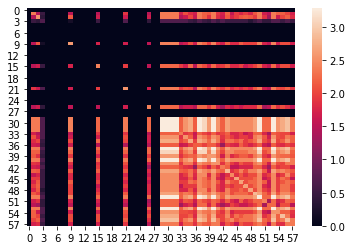

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

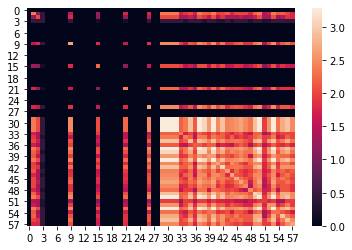

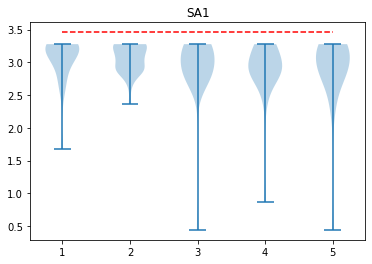

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

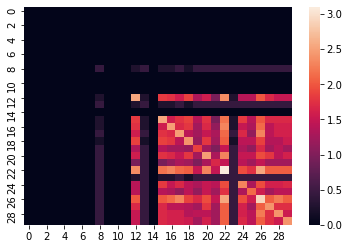

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

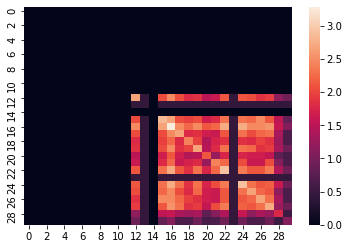

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

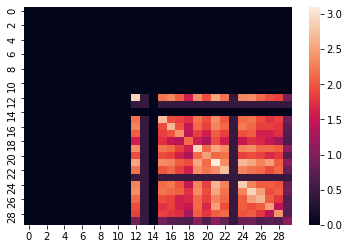

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

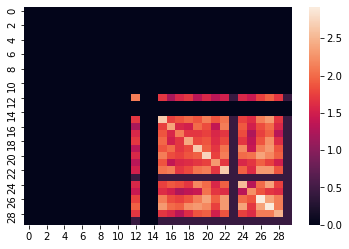

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

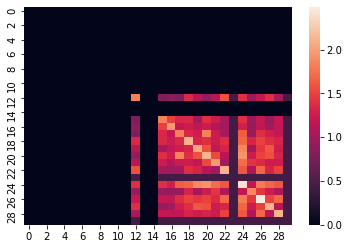

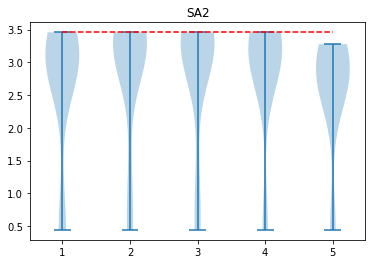

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

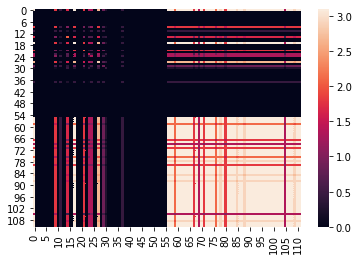

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

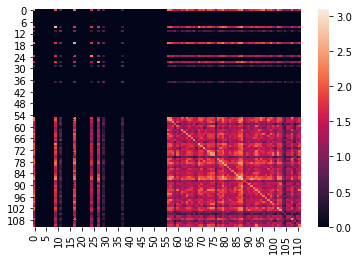

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

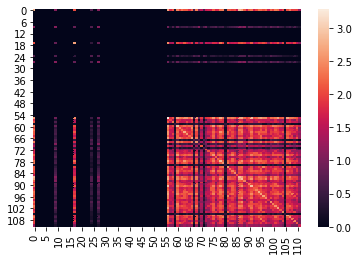

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

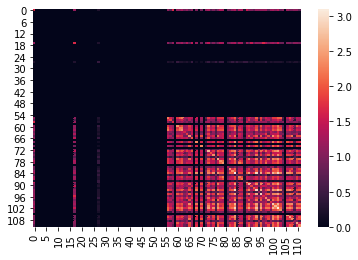

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

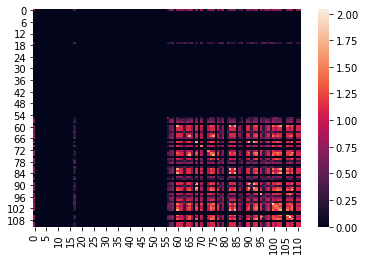

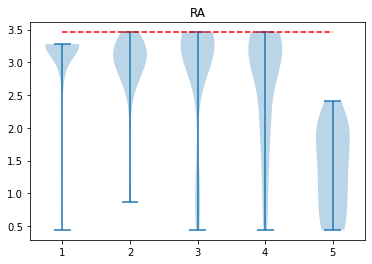

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

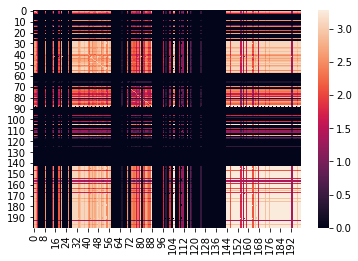

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

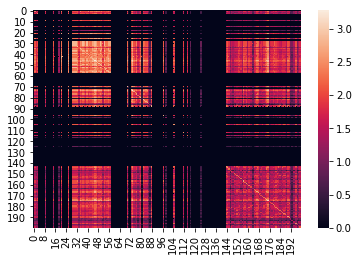

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

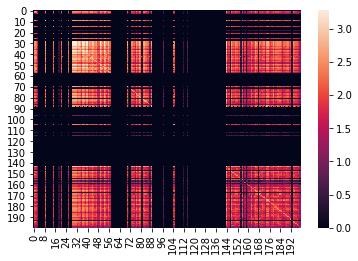

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

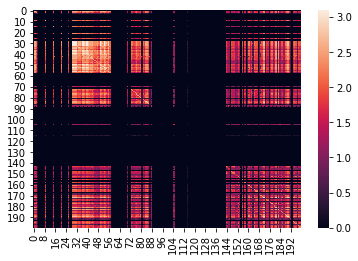

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

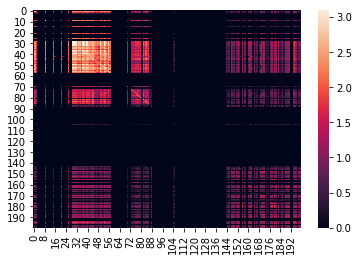

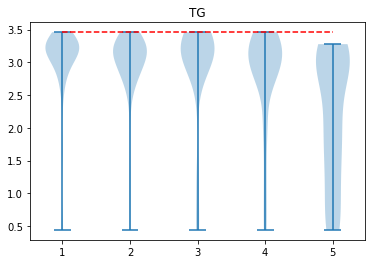

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

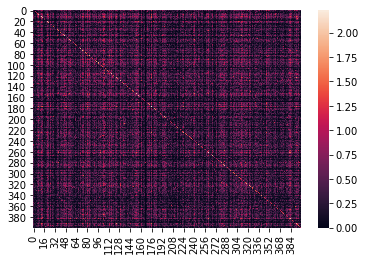

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

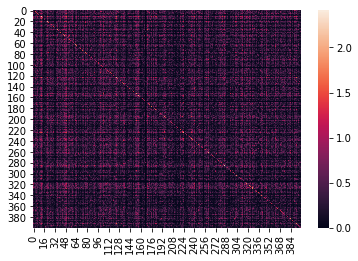

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

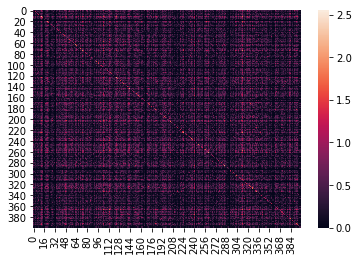

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

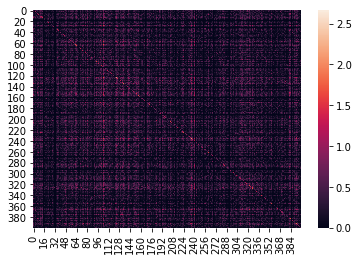

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

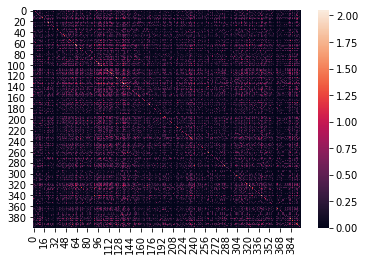

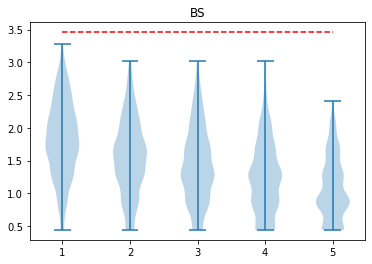

In [65]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
for k in range(len(Populations)):
    mi_per_neuron_per_pop = np.zeros((ranks, Populations_sizes[k]))
    for j in range(ranks):
        co_inf = np.zeros((Populations_sizes[k], Populations_sizes[k]))
        neural_act, stim_id = load_spiketime_per_neuron('0_slope_speed', '/' + Populations[k], Populations_sizes[k], j)
        for i in range(Populations_sizes[k]):
            mi_per_neuron_per_pop[j, i] = mutual_info_score(neural_act[:, i], stim_id)/np.log(2)
            for y in range(Populations_sizes[k]):
                co_inf[i, y] = co_information(neural_act[:, i], neural_act[:, y], stim_id)
        sns.heatmap(co_inf)
        plt.show()
    plt.violinplot([mi_per_neuron_per_pop[j, mi_per_neuron_per_pop[j, :] > 0] for j in range(ranks)])
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()